# 02 — Exploratory Analysis

Understand the traffic picture before doing any conflict detection. This notebook covers traffic density, altitude distributions, speed profiles, and directional patterns.

## 1. Load Data

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("../data/raw_states.csv", parse_dates=["time_utc"])
print(f"Loaded {len(df)} records, {df['icao24'].nunique()} unique aircraft")
df.describe()

Loaded 310 records, 53 unique aircraft


,time,lat,lon,altitude_ft,velocity_kts,heading_deg
count,3.100000e+02,310.000000,310.000000,310.000000,310.000000,310.000000
mean,1.773283e+09,32.784220,-97.050651,8203.548650,230.199324,156.739161
std,1.861601e+01,0.295404,0.305314,8545.898360,114.493068,128.925292
min,1.773283e+09,32.017600,-97.927700,200.000006,14.327280,0.000000
25%,1.773283e+09,32.629275,-97.160700,1756.250056,143.564400,16.532500
50%,1.773283e+09,32.812400,-97.032450,4637.500148,219.983040,168.485000
75%,1.773283e+09,32.970875,-96.868500,11700.000374,322.295760,275.832500
max,1.773283e+09,33.447100,-96.412800,36000.001152,493.037280,359.660000


## 2. Traffic Density

How many unique aircraft are airborne across each snapshot?

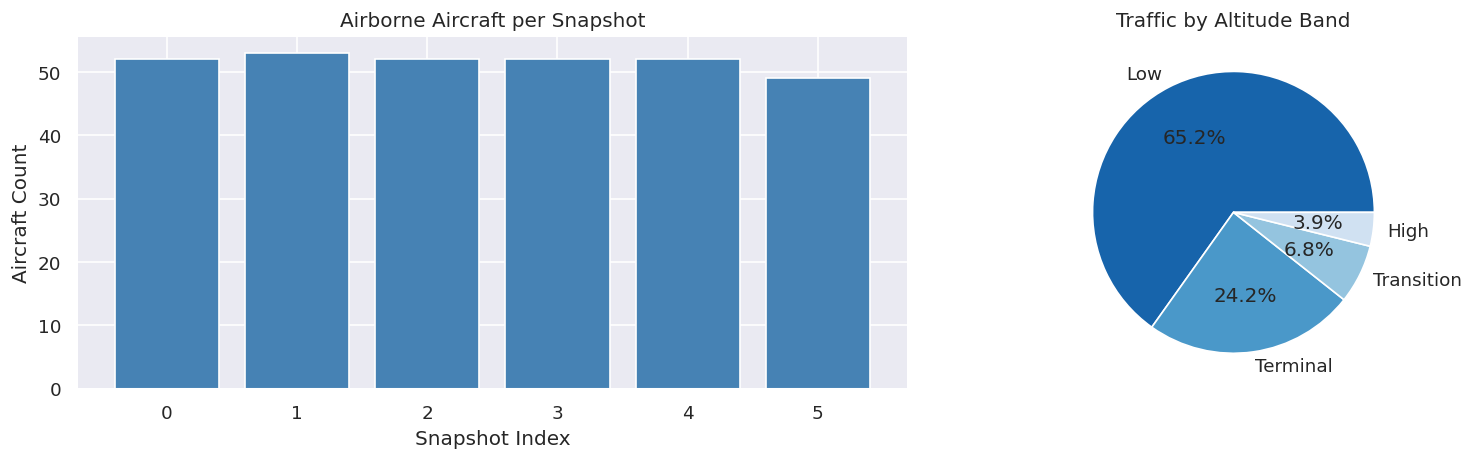

Peak aircraft count: 53


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Aircraft per snapshot
snapshot_counts = df.groupby("time")["icao24"].nunique()
axes[0].bar(range(len(snapshot_counts)), snapshot_counts.values, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Snapshot Index")
axes[0].set_ylabel("Aircraft Count")
axes[0].set_title("Airborne Aircraft per Snapshot")

# Altitude band distribution
alt_dist = df["alt_band"].value_counts()
axes[1].pie(alt_dist.values, labels=alt_dist.index, autopct="%1.1f%%",
            colors=sns.color_palette("Blues_r", len(alt_dist)))
axes[1].set_title("Traffic by Altitude Band")

plt.tight_layout()
plt.savefig("../outputs/02_traffic_density.png", bbox_inches="tight")
plt.show()
print(f"Peak aircraft count: {snapshot_counts.max()}")

## 3. Altitude & Speed Distributions

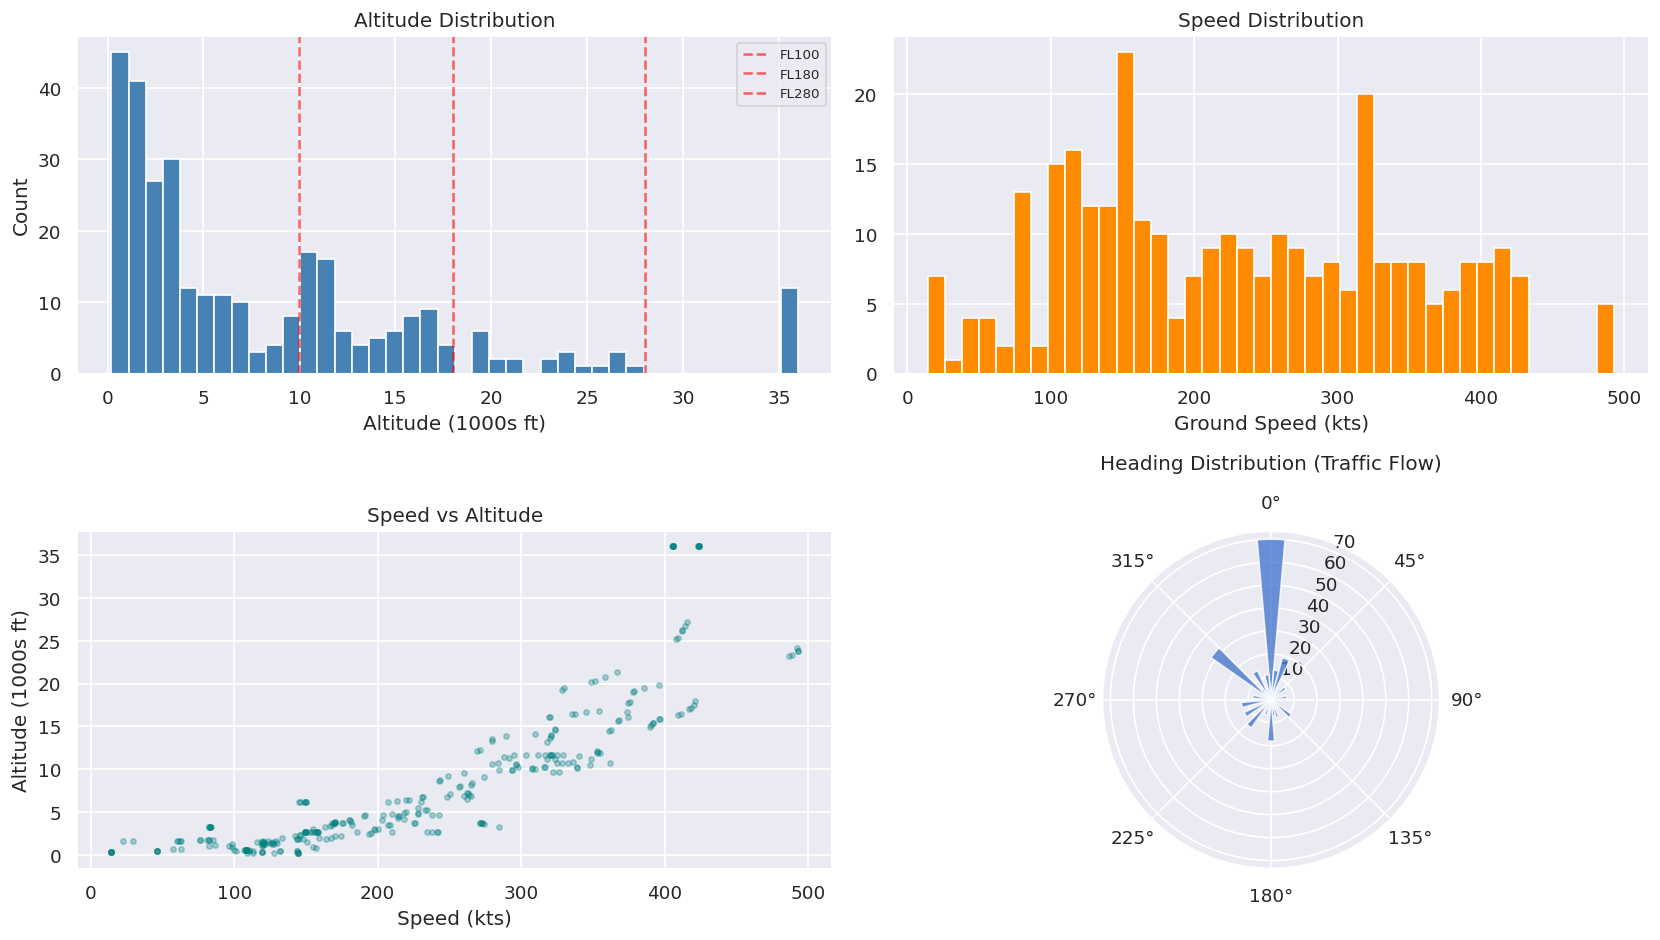

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Altitude histogram
axes[0,0].hist(df["altitude_ft"] / 1000, bins=40, color="steelblue", edgecolor="white")
axes[0,0].set_xlabel("Altitude (1000s ft)")
axes[0,0].set_ylabel("Count")
axes[0,0].set_title("Altitude Distribution")
for fl in [10, 18, 28]:  # major altitude transitions
    axes[0,0].axvline(fl, color="red", linestyle="--", alpha=0.6, label=f"FL{fl*10}")
axes[0,0].legend(fontsize=8)

# Speed histogram
axes[0,1].hist(df["velocity_kts"], bins=40, color="darkorange", edgecolor="white")
axes[0,1].set_xlabel("Ground Speed (kts)")
axes[0,1].set_title("Speed Distribution")

# Altitude vs Speed scatter
axes[1,0].scatter(df["velocity_kts"], df["altitude_ft"] / 1000,
                  alpha=0.3, s=10, c="teal")
axes[1,0].set_xlabel("Speed (kts)")
axes[1,0].set_ylabel("Altitude (1000s ft)")
axes[1,0].set_title("Speed vs Altitude")

# Heading rose (polar histogram)
ax_polar = fig.add_subplot(2, 2, 4, polar=True)
headings_rad = np.radians(df["heading_deg"].dropna())
bins = np.linspace(0, 2*np.pi, 37)
counts, _ = np.histogram(headings_rad, bins=bins)
width = (2*np.pi) / 36
bars = ax_polar.bar(bins[:-1], counts, width=width, edgecolor="white", alpha=0.8)
ax_polar.set_title("Heading Distribution (Traffic Flow)", pad=15)
ax_polar.set_theta_zero_location("N")
ax_polar.set_theta_direction(-1)

# Remove the 2,2 subplot placeholder
fig.delaxes(axes[1,1])

plt.tight_layout()
plt.savefig("../outputs/02_distributions.png", bbox_inches="tight")
plt.show()

## 4. Spatial Heatmap

Where is traffic most concentrated within the sector?

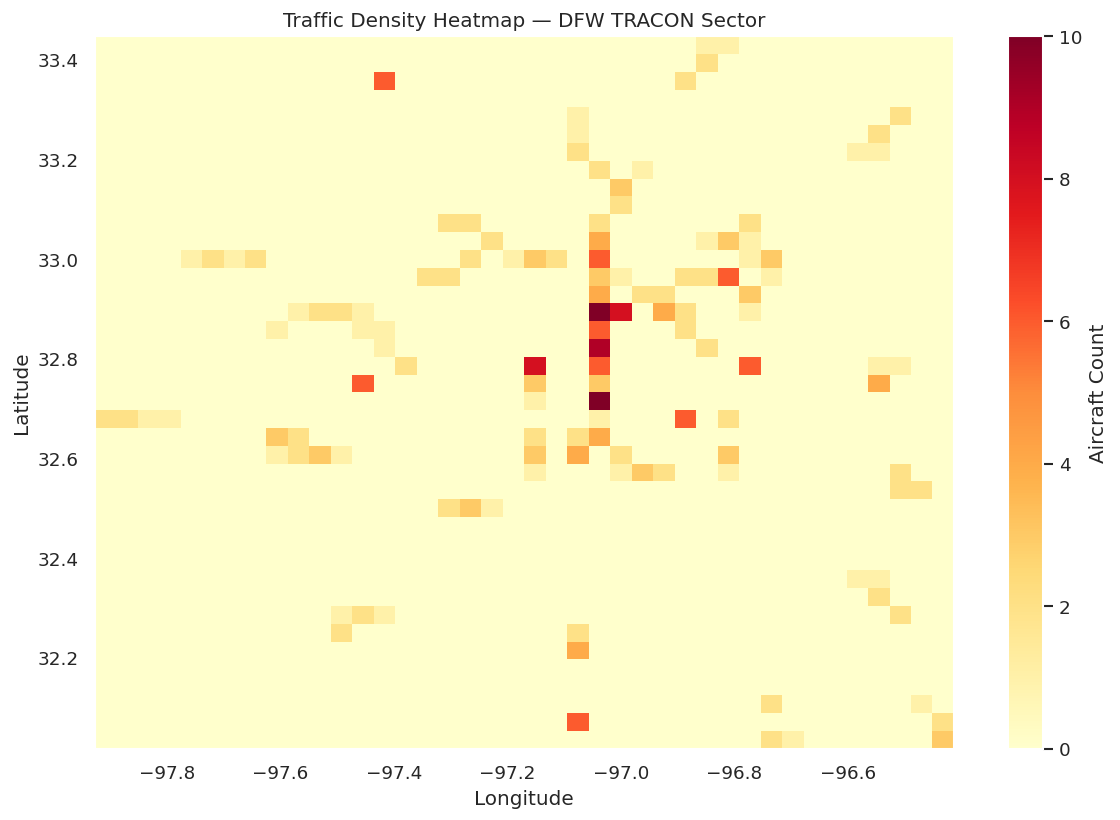

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))

h = ax.hist2d(df["lon"], df["lat"], bins=40,
              cmap="YlOrRd", density=False)
plt.colorbar(h[3], ax=ax, label="Aircraft Count")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Traffic Density Heatmap — DFW TRACON Sector")

plt.tight_layout()
plt.savefig("../outputs/02_heatmap.png", bbox_inches="tight")
plt.show()

## 5. Key Findings

Summarize what you observe — fill these in after running the notebook with real data.

- **Peak traffic:** ___ aircraft simultaneously airborne
- **Dominant altitude band:** ___
- **Average speed:** ___ kts
- **Dominant traffic flow direction:** ___
- **Highest-density area:** lat/lon ___, ___